 Introduction

This project aims to predict whether a passenger survived the Titanic disaster or not. It is a binary classification problem where the target variable indicates survival (1) or not (0). The dataset contains passenger details such as age, gender, ticket class, fare, and family information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dataset Overview

The dataset includes the following important features:

Pclass: Passenger class (1st, 2nd, 3rd)

Sex: Gender of the passenger

Age: Age of the passenger

SibSp: Number of siblings/spouses aboard

Parch: Number of parents/children aboard

Fare: Ticket fare

Embarked: Port of embarkation

Survived: Target variable (0 = No, 1 = Yes)

In [2]:
dataset = pd.read_csv("Titanic-Dataset.csv")
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
dataset.shape

(891, 12)

In [4]:
features_with_nan = [features for features in dataset.columns if dataset[features].isnull().sum()>1]
for feature in features_with_nan:
    print(feature,dataset[feature].isnull().mean()*100)

Age 19.865319865319865
Cabin 77.10437710437711
Embarked 0.22446689113355783



Data Cleaning

Dropped the Cabin column due to a high number of missing values (~77%)

Filled missing values in Age using the median (less affected by outliers)

Filled missing values in Embarked using the mode (most frequent value)

In [5]:
dataset.drop('Cabin',axis = 1,inplace=True)
dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())
dataset['Embarked'] = dataset['Embarked'].fillna(dataset['Embarked'].mode()[0])

In [6]:
dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [7]:
dataset["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [8]:
dataset["Sex"].unique()

array(['male', 'female'], dtype=object)

In [9]:
dataset["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [10]:
dataset["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

Exploratory Data Analysis (EDA)

Count plots were used to analyze survival 

Observed that:

Female passengers had higher survival rates

Passengers in higher classes (Pclass 1) had better survival chances

Histogram of Age helped understand age distribution

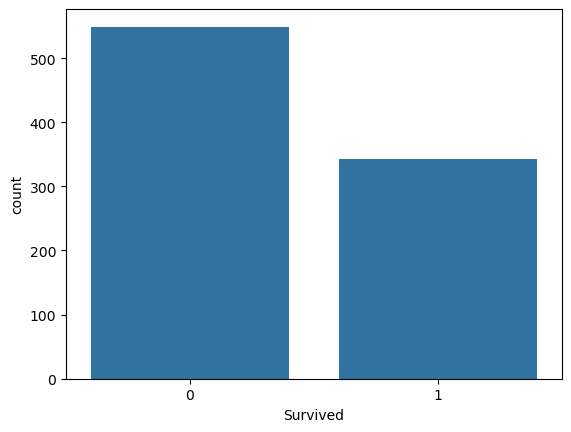

In [11]:
sns.countplot(x='Survived', data=dataset)
plt.show()

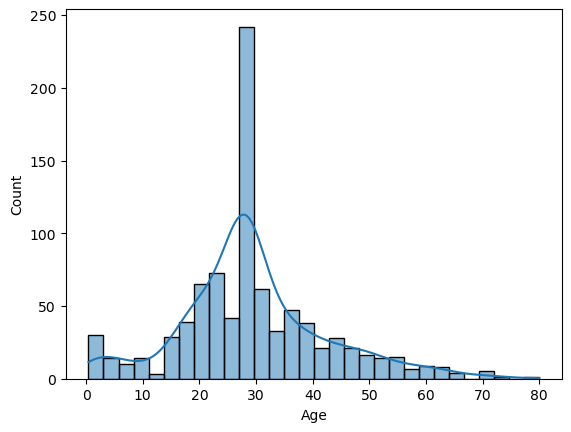

In [12]:
sns.histplot(dataset['Age'], kde=True)
plt.show()

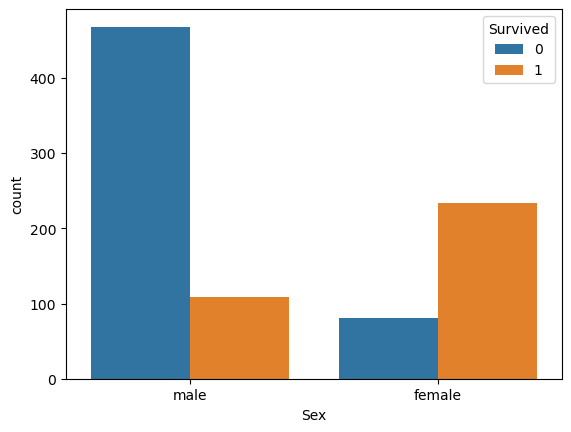

In [13]:
sns.countplot(x="Sex", hue="Survived", data=dataset)
plt.show()

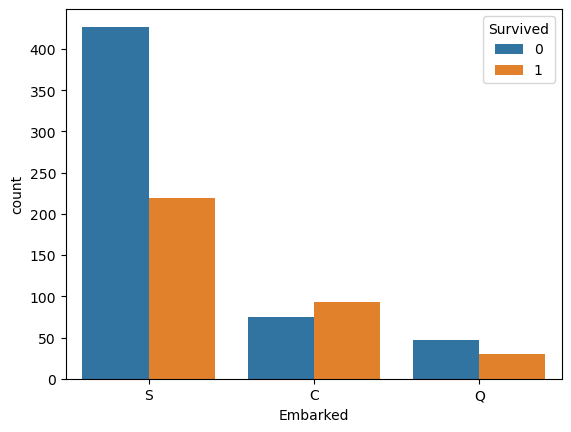

In [14]:
sns.countplot(x="Embarked", hue="Survived", data=dataset)
plt.show()

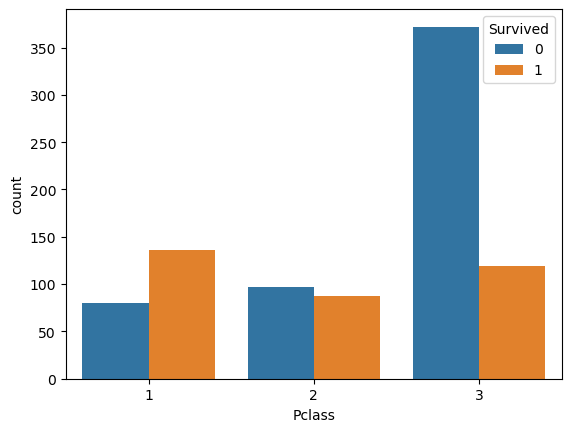

In [15]:
sns.countplot(x="Pclass", hue="Survived", data=dataset)
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

Data Preprocessing

Converted Sex into numerical form using label encoding:

Male → 1

Female → 0

Applied One-Hot Encoding on Embarked:
    
Created new columns: Embarked_Q, Embarked_S
    
Dropped unnecessary columns:
    
Name,
Ticket,
PassengerId

In [17]:
le = LabelEncoder()
dataset["Sex"] = le.fit_transform(dataset["Sex"])

In [18]:
dataset = pd.get_dummies(dataset, columns=['Embarked'], drop_first=True)

In [19]:
dataset[['Embarked_Q', 'Embarked_S']] = dataset[['Embarked_Q', 'Embarked_S']].astype(int)

In [20]:
dataset.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

Feature Engineering

Created a new feature FamilySize:

FamilySize = SibSp + Parch + 1

(Includes the passenger themselves)

Created IsAlone feature:

1 → Passenger is alone

0 → Passenger is not alone

Observed that passengers traveling alone had lower survival rates

In [21]:
dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
dataset['IsAlone'] = (dataset['FamilySize'] == 1).astype(int)

dataset.drop(['SibSp', 'Parch'], axis=1, inplace=True)

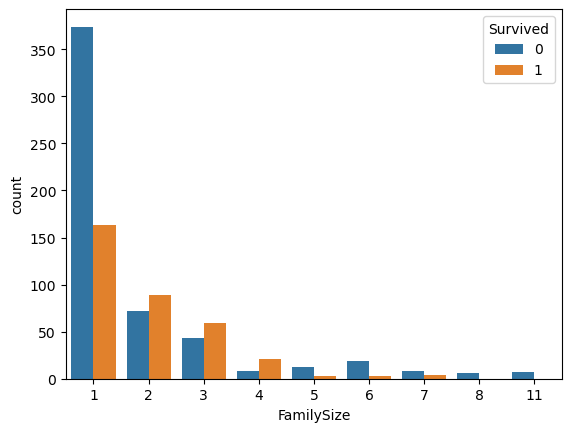

In [22]:
sns.countplot(x='FamilySize', hue='Survived', data=dataset)
plt.show()

In [23]:
dataset.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,1,22.0,7.2500,0,1,2,0
1,1,1,0,38.0,71.2833,0,0,2,0
2,1,3,0,26.0,7.9250,0,1,1,1
3,1,1,0,35.0,53.1000,0,1,2,0
4,0,3,1,35.0,8.0500,0,1,1,1


In [24]:
from sklearn.model_selection import train_test_split

Model Building

Split dataset into training and testing sets (75% training, 25% testing)

Used Logistic Regression for classification

In [25]:
input_data = dataset.drop('Survived', axis=1)
output_data = dataset['Survived']

In [26]:
x_train, x_test , y_train, y_test = train_test_split(input_data,output_data,test_size=0.25,random_state=42)

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
from sklearn.metrics import accuracy_score

Model Evaluation

Evaluated model using accuracy score

Achieved approximately 80% accuracy

In [30]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy*100)

80.26905829596413


In [31]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[115  19]
 [ 25  64]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       134
           1       0.77      0.72      0.74        89

    accuracy                           0.80       223
   macro avg       0.80      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223



“The model achieved around 80% accuracy. It performs better at predicting non-survivors compared to survivors, as seen from higher recall for class 0. The lower recall for survivors indicates that some actual survivors are misclassified. This is likely due to class imbalance in the dataset.”

Sample Prediction

Tested the model using custom input data

Verified that the model can predict survival for new, unseen passengers


In [32]:
sample_df = pd.DataFrame([{
    'Pclass': 2,
    'Sex': 0,
    'Age': 65,
    'Fare': 57.25,
    'Embarked_Q': 0,
    'Embarked_S': 1,
    'FamilySize': 3,
    'IsAlone': 0
}])

prediction = model.predict(sample_df)

if prediction[0] == 1:
    print("Survived")
else:
    print("Not Survived")

Survived


Conclusion

Survival was influenced by factors such as gender, passenger class, fare, and family size

Female passengers and those in higher classes had higher survival rates

Feature engineering improved model performance

Logistic Regression provided a good baseline model with satisfactory accuracy

In [33]:
import pickle

with open("titanic_model.pkl", "wb") as f:
    pickle.dump(model, f)